# Coffee shop sales — a first look

A short exploration of one month of (synthetic) orders from a little coffee shop. We load the data, tidy it up, summarise it, and draw a couple of plots.

> **FlowQuest tip:** open the sidebar and try the **Explain** action on a cell to earn *exploration* XP, then claim the missions that appear in the **Quest** tab.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=21)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=21)

rng = np.random.default_rng(seed=21)

## Load the orders

We synthesise a month of orders so the notebook runs anywhere.

In [2]:
n_orders = 600
drinks = ['espresso', 'latte', 'cappuccino', 'mocha', 'tea']
prices = {'espresso': 2.5, 'latte': 3.5, 'cappuccino': 3.5, 'mocha': 4.0, 'tea': 2.0}

orders = pd.DataFrame({
    'day': rng.integers(1, 31, size=n_orders),
    'hour': rng.integers(7, 19, size=n_orders),
    'drink': rng.choice(drinks, size=n_orders, p=[0.25, 0.3, 0.2, 0.15, 0.1]),
    'size': rng.choice(['S', 'M', 'L'], size=n_orders, p=[0.3, 0.45, 0.25]),
})
orders = pd.DataFrame({
    'day': rng.integers(1, 31, size=n_orders),
    'hour': rng.integers(7, 19, size=n_orders),
    'drink': rng.choice(drinks, size=n_orders, p=[0.25, 0.3, 0.2, 0.15, 0.1]),
    'size': rng.choice(['S', 'M', 'L'], size=n_orders, p=[0.3, 0.45, 0.25]),
})
orders.head()
    'size': rng.choice(['S', 'M', 'L'], size=n_orders, p=[0.3, 0.45, 0.25]),
})
orders.head()

,day,hour,drink,size
0,10,17,latte,L
1,24,15,mocha,S
2,12,17,tea,M
3,19,18,cappuccino,M
4,14,16,mocha,M


## Clean & enrich

Derive the price for each order and a simple part-of-day label.

In [3]:
size_multiplier = {'S': 1.0, 'M': 1.2, 'L': 1.5}
orders['price'] = (
    orders['drink'].map(prices) * orders['size'].map(size_multiplier)
).round(2)

def part_of_day(hour: int) -> str:
    if hour < 11:
        return 'morning'
    if hour < 15:
        return 'midday'
    return 'afternoon'

orders['part_of_day'] = orders['hour'].map(part_of_day)
orders.head()

,day,hour,drink,size,price,part_of_day
0,10,17,latte,L,5.25,afternoon
1,24,15,mocha,S,4.00,afternoon
2,12,17,tea,M,2.40,afternoon
3,19,18,cappuccino,M,4.20,afternoon
4,14,16,mocha,M,4.80,afternoon


## Explore

A few quick questions: what sells, and when?

In [4]:
orders['drink'].value_counts()

drink
latte         167
espresso      140
cappuccino    123
mocha         103
tea            67
Name: count, dtype: int64

In [5]:
orders.groupby('part_of_day')['price'].agg(['count', 'sum', 'mean']).round(2)

,count,sum,mean
part_of_day,,,
afternoon,185,733.75,3.97
midday,199,739.90,3.72
morning,216,848.35,3.93


## Visualise

Revenue by drink, and orders across the day.

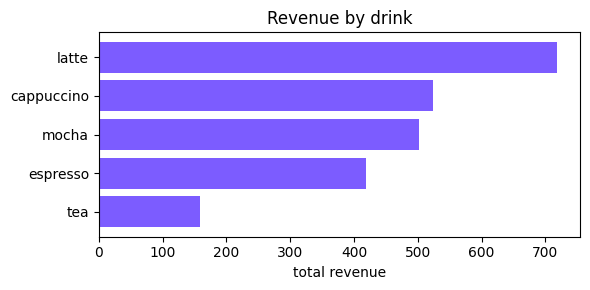

In [6]:
revenue = orders.groupby('drink')['price'].sum().sort_values()

fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(revenue.index, revenue.values, color='#7c5cff')
ax.set_xlabel('total revenue')
ax.set_title('Revenue by drink')
plt.tight_layout()
plt.show()

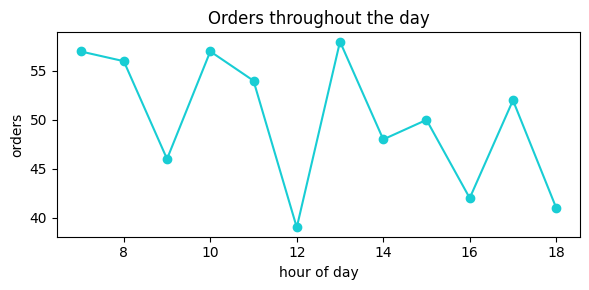

In [7]:
by_hour = orders.groupby('hour').size()

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(by_hour.index, by_hour.values, marker='o', color='#18cdd4')
ax.set_xlabel('hour of day')
ax.set_ylabel('orders')
ax.set_title('Orders throughout the day')
plt.tight_layout()
plt.show()

## Reflect

What's the single most surprising thing in these plots? Open a cell's FlowQuest chip and pick **Reflect** to put it in words and earn *reflection* XP.